# TAKE AWAY

## Version 0

Dans cette version:
- Mise à l'écart de la classe `Other` sans rétirer les rapports consernés car cooccurence avec d'autres labels
- Retrait de 15 rapports avec `Other` uniquement
- Imputation NSAO uniquement pour les rapport NSAO + un autre label
- Calcul des poids avec la méthode max(Ni) / Ni
-  AdamW
- FocalLoss paramètres par défaut
- etc. voir (W&B)

1. L'évaluation OOF est consistente avec le test set:
    - OOF: `macro avg       0.69      0.73      0.71    181730`
    - Test: `macro avg       0.69      0.74      0.71     21076`
    - OOF: threshold : [0.44 0.46 0.43 0.45 0.44 0.41 0.43 0.47 0.43 0.42 0.45 0.42 0.44 0.31] score : 0.70867586
    - Test: threshold : [0.44 0.46 0.43 0.45 0.44 0.41 0.43 0.47 0.43 0.42 0.45 0.42 0.44 0.31] score : 0.7114698
    - Une amélioration dans le score OOF serait donc un bon indicateur de la performance sur `Test`
    - Un `delta` de 0.2 environ entre l'évalution individuelle de chaque fold et l'`OOF` et le `Test` -> tester rapidement sur un fold
2. Précision à améliorer surtout
3. Pas de différence entre distribution probs TP/FP
4. *`Perfs similaires au projet SAFRAN en entraînant moins de couches`*

# CONTENT

In [1]:
import json
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from omegaconf import OmegaConf
from sklearn.metrics import (
    classification_report,
    fbeta_score,
    confusion_matrix,
    multilabel_confusion_matrix,
)
from torchmetrics.functional import f1_score
from tqdm.auto import tqdm

from asrsclassifier.data import load_data
from asrsclassifier.config import path, wandbgroup

OmegaConf.register_new_resolver("eval", resolver=eval, replace=True)
OmegaConf.register_new_resolver("wandbgroup", resolver=wandbgroup, replace=True)
OmegaConf.register_new_resolver("path", resolver=path, replace=True)

In [2]:
def plot_cooc(cooc, mask, labels, **kwargs):
    plt.figure(figsize=kwargs["figsize"])

    ax = sns.heatmap(
        cooc,
        yticklabels=labels,
        xticklabels=labels,
        annot=kwargs["annot"],
        cmap=kwargs["cmap"],
        mask=mask,
        annot_kws={"size": kwargs["annot_kws"]},
    )

    ax.set_title(kwargs["title"], fontsize=10)

    ax.tick_params(axis="x", labelsize=kwargs["x_labelsize"])
    ax.tick_params(axis="y", labelsize=kwargs["y_labelsize"])

    plt.tight_layout()
    plt.show()

In [3]:
cfg = OmegaConf.load("/kaggle/working/asrs_data/src/asrsclassifier/config/config.yaml")

In [4]:
with open("../data/01_primary/one_hot_mapping.json", "r") as f:
    mapping = json.load(f)
mapping

{'ATC Issue': 0,
 'Aircraft Equipment': 1,
 'Airspace Violation': 2,
 'Conflict': 3,
 'Deviation - Altitude': 4,
 'Deviation - Speed': 5,
 'Deviation - Track/Heading': 6,
 'Deviation/Discrepancy - Procedural': 7,
 'Flight Deck/Cabin/Aircraft Event': 8,
 'Ground Event/Encounter': 9,
 'Ground Excursion': 10,
 'Ground Incursion': 11,
 'Inflight Event/Encounter': 12,
 'No Specific Anomaly Occurred': 13}

## OOF

In [32]:
VERSION = "version_0"
pred_glob = glob(
    f"/kaggle/working/asrs_data/logs/seed_4294967295/**/{VERSION}/preds*.pt",
    recursive=True,
)
pred_glob = [f for f in pred_glob if "fold-1" not in f]

In [20]:
output = torch.cat([torch.load(f) for f in pred_glob])

In [21]:
output = torch.unique(output, dim=0)

In [76]:
ypred = output[:, 1:15]
ytrue = output[:, 15:]

In [28]:
def compute_best_score(preds, target, precision=0.01):
    ths = np.arange(start=0.0, stop=1.0, step=precision)
    class_scores_list = []
    for t in tqdm(ths):
        score = f1_score(
            threshold=t,
            preds=preds,
            target=target,
            task="multilabel",
            num_labels=14,
            average="none",
        ).numpy()
        class_scores_list += [score]
    scores_per_class = np.array(class_scores_list)
    best_idx_per_class = np.argmax(scores_per_class, axis=0)
    best_thd_per_class = ths[best_idx_per_class]
    best_scores_per_label = [
        scores_per_class[i, c] for c, i in enumerate(best_idx_per_class)
    ]
    score = np.mean(best_scores_per_label)
    std = np.std(best_scores_per_label)
    return best_thd_per_class, score, std

In [77]:
thds, score, std = compute_best_score(ypred, ytrue)

  0%|          | 0/100 [00:00<?, ?it/s]

In [80]:
print("threshold :", thds, "score :", score)

threshold : [0.44 0.46 0.43 0.45 0.44 0.41 0.43 0.47 0.43 0.42 0.45 0.42 0.44 0.31] score : 0.70867586


In [79]:
print(
    classification_report(
        ytrue.numpy(), (ypred.numpy() > thds), target_names=mapping.keys()
    )
)

                                    precision    recall  f1-score   support

                         ATC Issue       0.71      0.77      0.74     14969
                Aircraft Equipment       0.85      0.89      0.87     36011
                Airspace Violation       0.69      0.67      0.68      3827
                          Conflict       0.79      0.84      0.81     16272
              Deviation - Altitude       0.72      0.74      0.73      8342
                 Deviation - Speed       0.58      0.66      0.61      2489
         Deviation - Track/Heading       0.71      0.70      0.71      7881
Deviation/Discrepancy - Procedural       0.78      0.89      0.83     54910
  Flight Deck/Cabin/Aircraft Event       0.79      0.75      0.77      6712
            Ground Event/Encounter       0.63      0.70      0.67      6728
                  Ground Excursion       0.78      0.76      0.77      1995
                  Ground Incursion       0.70      0.81      0.75      5000
          I

/root/.pyenv/versions/asrs/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [33]:
labels = (ypred.numpy() > thds).astype(np.int32)

In [34]:
cooc = ((labels.T @ labels) / labels.shape[0]) * 100
mask = np.triu(np.ones_like(cooc, dtype=bool), k=1)

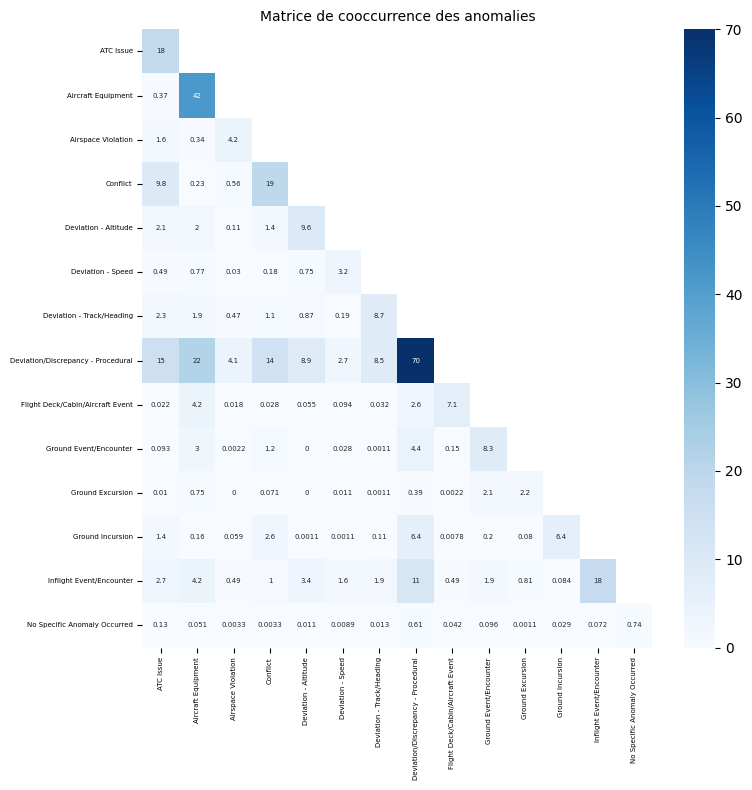

In [35]:
plot_cooc(
    cooc,
    mask,
    mapping.keys(),
    figsize=(8, 8),
    annot=True,
    cmap="Blues",
    annot_kws=5,
    title="Matrice de cooccurrence des anomalies",
    x_labelsize=5,
    y_labelsize=5,
)

In [36]:
target_np = ytrue.bool().numpy()

tp = (labels == 1) & target_np
fn = (labels == 0) & target_np
fp = (labels == 1) & (~target_np)

<Axes: ylabel='Count'>

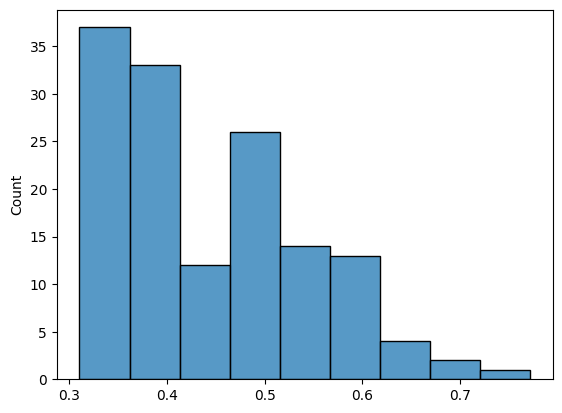

In [37]:
sns.histplot(ypred[:, -1][tp[:, -1]])

<Axes: ylabel='Count'>

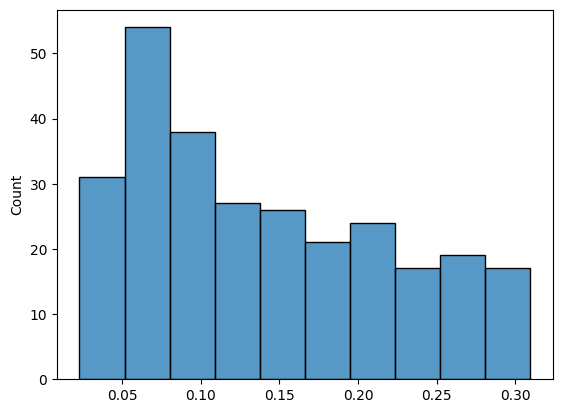

In [38]:
sns.histplot(ypred[:, -1][fn[:, -1]])

<Axes: ylabel='Count'>

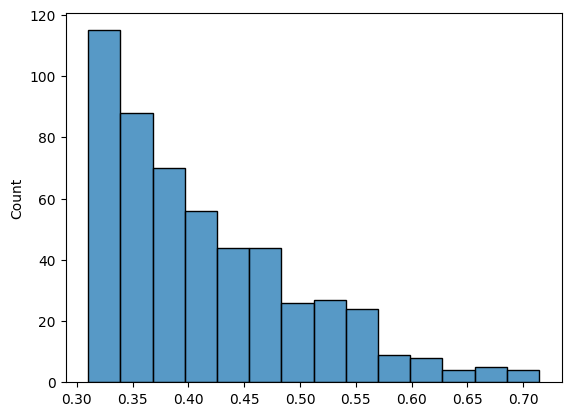

In [39]:
sns.histplot(ypred[:, -1][fp[:, -1]])

In [40]:
def floss(p, target, alpha, gamma, weight):
    loss = (-alpha * ((1 - p) ** gamma) * np.log(p) * target).mean(axis=0)
    loss = np.array(weight) * loss
    return loss, loss.mean()

In [41]:
floss(ypred.numpy(), ytrue.numpy(), 1, 2, np.ones(14).tolist())

(array([0.03090735, 0.03574399, 0.01266896, 0.02526628, 0.02003483,
        0.01024819, 0.02199261, 0.05640113, 0.01833176, 0.02105574,
        0.00537234, 0.01147325, 0.04018251, 0.00560168]),
 0.02252004498482815)

In [47]:
floss(
    ypred.numpy(),
    ytrue.numpy(),
    10,
    0.01,
    [4, 2, 13, 3, 7, 22, 7, 1, 8, 8, 28, 11, 3, 124],
)

(array([4.16785049, 3.31633854, 4.13392237, 2.86574328, 4.2206127 ,
        5.07087669, 4.24520355, 2.92961121, 3.80689263, 4.53902292,
        3.85555637, 3.91383249, 3.5929867 , 9.75732347]),
 4.315412387251854)

## TEST SET EVALUATION

In [81]:
test_glob = glob(
    f"/kaggle/working/asrs_data/logs/seed_4294967295/**fold-1/{VERSION}/preds*.pt",
    recursive=True,
)

In [82]:
test = torch.cat([torch.load(f) for f in test_glob])

In [83]:
test = torch.unique(test, dim=0)

In [84]:
ypred = test[:, 1:15]
ytrue = test[:, 15:]

In [85]:
thds_t, score, std = compute_best_score(ypred, ytrue)

  0%|          | 0/100 [00:00<?, ?it/s]

In [86]:
print("threshold :", thds, "score :", score)

threshold : [0.44 0.46 0.43 0.45 0.44 0.41 0.43 0.47 0.43 0.42 0.45 0.42 0.44 0.31] score : 0.7114698


In [87]:
print(
    classification_report(
        ytrue.numpy(), (ypred.numpy() > thds_t), target_names=mapping.keys()
    )
)

                                    precision    recall  f1-score   support

                         ATC Issue       0.76      0.84      0.80      2399
                Aircraft Equipment       0.89      0.85      0.87      4019
                Airspace Violation       0.62      0.64      0.63       383
                          Conflict       0.82      0.85      0.83      1715
              Deviation - Altitude       0.68      0.73      0.71       881
                 Deviation - Speed       0.56      0.72      0.63       356
         Deviation - Track/Heading       0.72      0.68      0.70       820
Deviation/Discrepancy - Procedural       0.75      0.89      0.82      5813
  Flight Deck/Cabin/Aircraft Event       0.77      0.69      0.73       843
            Ground Event/Encounter       0.68      0.70      0.69       849
                  Ground Excursion       0.75      0.85      0.80       265
                  Ground Incursion       0.68      0.74      0.71       419
          I

/root/.pyenv/versions/asrs/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [88]:
print(
    classification_report(
        ytrue.numpy(), (ypred.numpy() > thds), target_names=mapping.keys()
    )
)

                                    precision    recall  f1-score   support

                         ATC Issue       0.81      0.75      0.78      2399
                Aircraft Equipment       0.85      0.89      0.87      4019
                Airspace Violation       0.67      0.58      0.62       383
                          Conflict       0.77      0.89      0.83      1715
              Deviation - Altitude       0.72      0.68      0.70       881
                 Deviation - Speed       0.64      0.61      0.62       356
         Deviation - Track/Heading       0.62      0.76      0.68       820
Deviation/Discrepancy - Procedural       0.73      0.91      0.81      5813
  Flight Deck/Cabin/Aircraft Event       0.76      0.70      0.73       843
            Ground Event/Encounter       0.69      0.68      0.68       849
                  Ground Excursion       0.67      0.91      0.77       265
                  Ground Incursion       0.59      0.84      0.69       419
          I

/root/.pyenv/versions/asrs/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
